## Préparation

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

orders = pd.read_csv("data/orders.csv")
order_products = pd.read_csv("data/order_products.csv")
products = pd.read_csv("data/products.csv")
aisles = pd.read_csv("data/aisles.csv")
departments = pd.read_csv("data/departments.csv")

df = (
    order_products
    .merge(orders, on="order_id", how="left")
    .merge(products, on="product_id", how="left")
    .merge(aisles, on="aisle_id", how="left")
    .merge(departments, on="department_id", how="left")
)


## Nettoyage des données

In [14]:
#------------------------------------------------------   NETTOYAGE

#dropna ou filna

df = df.dropna(subset=["product_id"])
df["reordered"] = df["reordered"].fillna(0)
df = df.dropna(subset=["user_id"])

# colonnes à convertir en entier
cols_to_int = [
    "product_id", 
    "add_to_cart_order", 
    "reordered", 
    "user_id", 
    "order_number", 
    "order_dow", 
    "aisle_id", 
    "department_id"
]

# convertir en entier  (int64 pour les nan)
df[cols_to_int] = df[cols_to_int].astype("Int64")

# Remplacements colonnes valeurs: 
df["order_number"], df["order_dow"] = df["order_dow"], df["order_number"]

df["order_number"], df["order_hour_of_day"] = df["order_hour_of_day"], df["order_number"]

#------------------------------------------------------------------------- NETTOYAGE

## Nombre total de commandes

In [15]:
total_orders = df["order_id"].nunique()
print("Nombre total de commandes :", total_orders)

Nombre total de commandes : 1357511


## Nombre total de produits

In [16]:
total_products = df["product_id"].nunique()
print("Nombre total de produits :", total_products)

Nombre total de produits : 49067


## Produits par commande

In [17]:
product_par_basket = df.groupby("order_id")["product_id"].count()

## Panier moyen

In [18]:
average_basket = product_par_basket.mean()
print("Panier moyen :", round(average_basket, 1))

Panier moyen : 10.1


## Top des produits les plus vendus

In [19]:
lemost = df.groupby(["product_id", "product_name"]).size().sort_values(ascending=False)
print(lemost.head())

product_id  product_name          
24852       Banana                    199647
13176       Bag of Organic Bananas    160613
21137       Organic Strawberries      111972
21903       Organic Baby Spinach      101911
47209       Organic Hass Avocado       90368
dtype: int64


# Départements les plus populaires

In [20]:
dept_popularity = df.groupby(["department_id", "department"]).size().reset_index(name="nb_ventes").sort_values(by="nb_ventes", ascending=False)
dept_popularity.head()

,department_id,department,nb_ventes
3,4,produce,4005228
15,16,dairy eggs,2286342
18,19,snacks,1216498
6,7,beverages,1135998
0,1,frozen,943878


## Commandes par jours

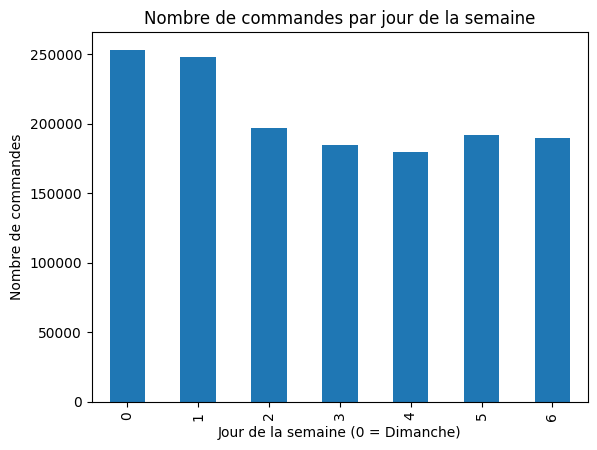

In [21]:
# compter le nombre de commandes par jour (0=Dimanche)
orders_per_day = (
	orders.dropna(subset=["order_dow"])
	.assign(order_dow=lambda x: x["order_dow"].astype(int))
	.loc[lambda x: x["order_dow"].between(0, 6)]
	.groupby("order_dow")["order_id"]
	.nunique()
	.reindex(range(7), fill_value=0)
)

# graphique
orders_per_day.plot(kind="bar")

plt.title("Nombre de commandes par jour de la semaine")
plt.xlabel("Jour de la semaine (0 = Dimanche)")
plt.ylabel("Nombre de commandes")

plt.show()

## Reorder selon la position dans le panier

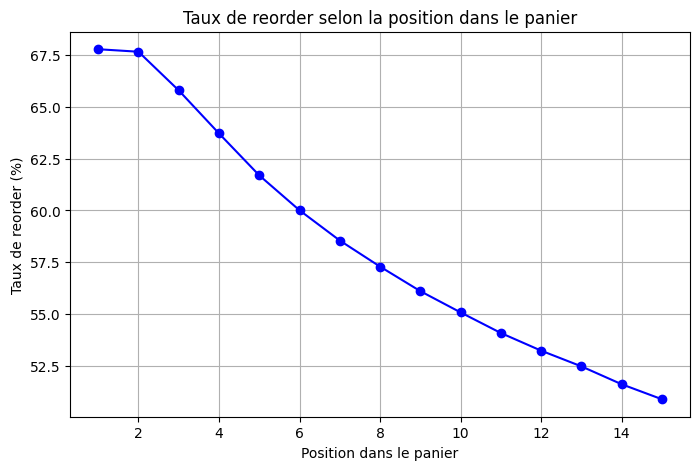

In [22]:
# calcul du reorder
reorder_by_position = (
    order_products.groupby("add_to_cart_order")["reordered"]
    .mean()
    .reset_index()
)

# 15 remirs
reorder_by_position = reorder_by_position.head(15)

# en pourcentage
reorder_by_position["reordered_pct"] = reorder_by_position["reordered"] * 100

# graphique
plt.figure(figsize=(8,5))
plt.plot(reorder_by_position["add_to_cart_order"],
         reorder_by_position["reordered_pct"],
         marker="o", linestyle="-", color="blue")

plt.xlabel("Position dans le panier")
plt.ylabel("Taux de reorder (%)")
plt.title("Taux de reorder selon la position dans le panier")
plt.grid(True)
plt.show()

##### l’analyse du taux de reorder par position dans le panier montre que les produits ajoutés en début de panier sont reorder plus fréquemment que ceux placés en fin de panier. Cela indique que les clients achètent régulièrement leurs articles favoris en premier, ce qui reflète à la fois leurs habitudes et la priorité accordée à certains produits dans leurs commandes.

# Les produits dans les petits paniers sont ils les plus reorder ?

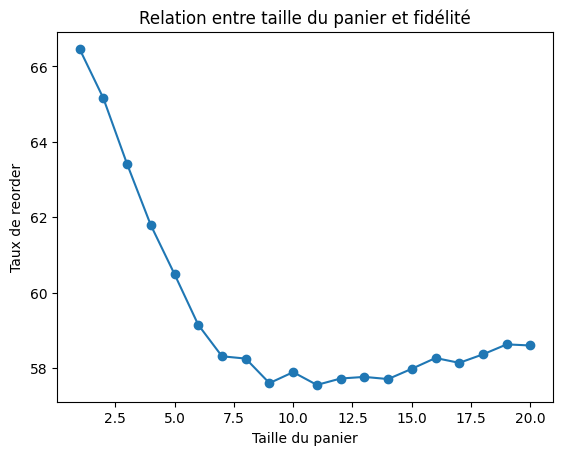

In [23]:
# taille du panier
cart_size = order_products.groupby("order_id").size().reset_index(name="cart_size")

# taux reorder moyen par commande
reorder_rate = order_products.groupby("order_id")["reordered"].mean().reset_index()

# fusionner
basket_df = cart_size.merge(reorder_rate, on="order_id")

# taux moyen de reorder selon la taille du panier
result = basket_df.groupby("cart_size")["reordered"].mean().reset_index()

# 20 premiers
result = result.head(20)

result["reordered"] = result["reordered"] * 100
# graphique
plt.figure()
plt.plot(result["cart_size"], result["reordered"], marker="o")

plt.xlabel("Taille du panier")
plt.ylabel("Taux de reorder")
plt.title("Relation entre taille du panier et fidélité")
plt.show()

##### Oui, nous observons que les plus petits paniers, qui contiennent souvent des articles essentiels comme l’eau, les œufs, le pain ou le lait, présentent un taux de reorder supérieur à 60 %. Cela signifie que ces produits sont rachetés plus de la moitié du temps, ce qui reflète leur caractère indispensable dans les habitudes d’achat des clients.

## Premier produit mit dans le panier

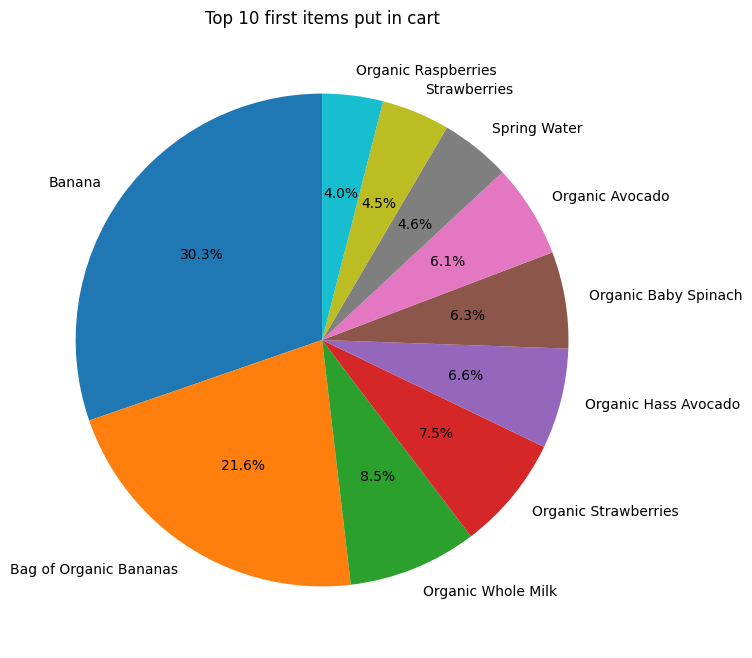

In [24]:

first_items = df[df["add_to_cart_order"] == 1]
top_first = first_items["product_name"].value_counts().head(10)

# graphique camembert
plt.figure(figsize=(8, 8))
plt.pie(top_first.values, labels=top_first.index, autopct="%1.1f%%", startangle=90)
plt.title("Top 10 first items put in cart")
plt.show()

## Optimiser le placement produit en magasin

 - Les rayons à la fois très vendus et très reachetés méritent les meilleures places (entrée, allées centrales, hauteur des yeux).

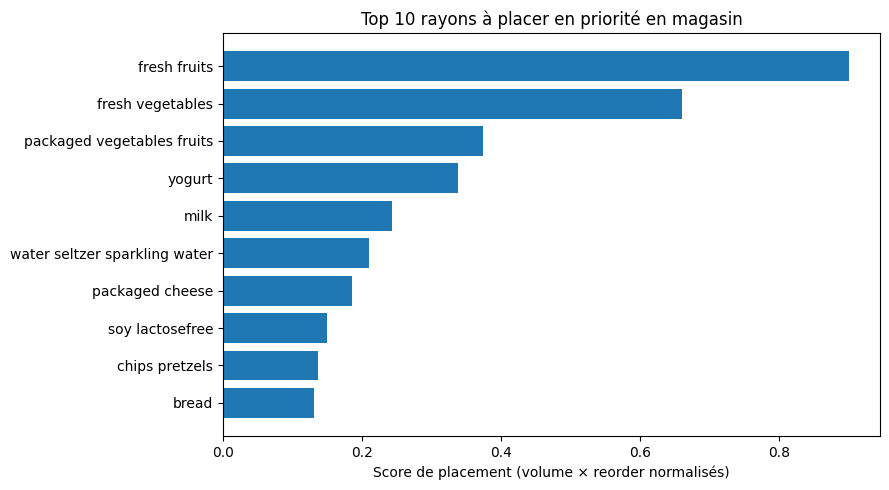

In [25]:
# score de placement par rayon (aisle)

# df (aisle + reordered)
aisle_stats = (
    df.groupby("aisle")
    .agg(volume=("product_id", "count"), reorder_rate=("reordered", "mean"))
    .reset_index()
)

# normaliser (sinon ca fausse tout)
aisle_stats["vol_norm"] = (aisle_stats["volume"] - aisle_stats["volume"].min()) / (aisle_stats["volume"].max() - aisle_stats["volume"].min())
aisle_stats["ror_norm"] = (aisle_stats["reorder_rate"] - aisle_stats["reorder_rate"].min()) / (aisle_stats["reorder_rate"].max() - aisle_stats["reorder_rate"].min())

# score de l'allée = volume × reorder
aisle_stats["placement_score"] = aisle_stats["vol_norm"] * aisle_stats["ror_norm"]

# top 10 rayons 
top_aisles = aisle_stats.sort_values("placement_score", ascending=False).head(10)

# graphique
plt.figure(figsize=(9, 5))
plt.barh(top_aisles["aisle"][::-1], top_aisles["placement_score"][::-1])
plt.xlabel("Score de placement (volume × reorder normalisés)")
plt.title("Top 10 rayons à placer en priorité en magasin")
plt.tight_layout()
plt.show()

 ##### Pour maximiser les profits du magasin il faudrait placer les fruits et légumes frais à l’entrée du magasin ou dans les allées centrales, car ils attirrent beaucoup de mondes et sont souvent recommandés. Les produits comme le yaourt ou le lait, pourraient êtres placés à hauteur des yeux dans les rayons frais, pour optimiser leur visibilité et favoriser l’achat d’impulsion. Pour finir, les produits de consommation quotidienne, comme  l’eau ou le pain, doivent être placé de façon a être facilement accessibles car ils attirent beaucoup de monde aussi mais ne doivent pas bloquer le trafic.